# Pythonチャレンジ: 地震データを探る

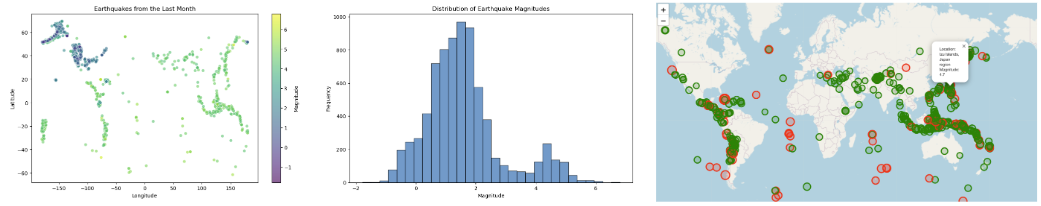

目的: Pythonを使ってUSGS（アメリカ地質調査所）のリアルタイム地震APIから最新の地震データを取得し、意味のある分析を行います。このチャレンジの最終目標は、世界中の地震を視覚化することです。

## 始めに

参考リンク：

- USGS 地震プログラム ホームページ: https://www.usgs.gov/programs/earthquake-hazards/earthquakes
- リアルタイムCSVデータ（スプレッドシート）API: https://earthquake.usgs.gov/earthquakes/feed/v1.0/csv.php

データの取得: USGSのリアルタイム地震APIを使用して、最新の地震データを取得します。APIの基本URLは以下の通りです：

https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv

以下のPythonスクリプトを作成して：
- APIにリクエストを送信。
- csv形式のレスポンスを解析し、各地震の位置、マグニチュード、深さ、発生時刻などの情報を抽出します。

### リクエストコード例

In [8]:
import pandas as pd
import requests

# USGSから過去1か月の地震データを取得
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"
response = requests.get(url)

# データをファイルに保存
with open('earthquakes.csv', 'wb') as file:
    file.write(response.content)

# データをDataFrameに読み込む
data = pd.read_csv('earthquakes.csv')

# データの最初の5行を表示
data.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2025-11-17T06:13:40.490Z,36.682667,-121.344498,2.4800,2.73,md,48.0,50.0,0.02480,0.21,...,2025-11-17T06:15:15.640Z,"12 km S of Tres Pinos, CA",earthquake,0.26,0.770000,0.150,60.0,automatic,nc,nc
1,2025-11-17T06:05:35.090Z,19.164833,-155.498001,31.1000,1.97,ml,53.0,117.0,0.03520,0.13,...,2025-11-17T06:09:46.130Z,"4 km SSW of Pāhala, Hawaii",earthquake,0.53,0.600000,0.770,6.0,automatic,hv,hv
2,2025-11-17T06:02:50.330Z,33.483833,-116.549667,8.8800,0.60,ml,28.0,50.0,0.04522,0.13,...,2025-11-17T06:06:17.568Z,"14 km SE of Anza, CA",earthquake,0.17,0.400000,0.164,16.0,automatic,ci,ci
3,2025-11-17T05:59:50.526Z,31.708000,-104.263000,4.0224,1.40,ml,26.0,52.0,0.00000,0.20,...,2025-11-17T06:04:10.708Z,"52 km SSE of Whites City, New Mexico",earthquake,0.00,1.056292,0.200,18.0,automatic,tx,tx
4,2025-11-17T05:44:41.450Z,33.455667,-116.435500,5.1300,0.61,ml,33.0,45.0,0.14050,0.19,...,2025-11-17T05:48:14.214Z,"23 km NNW of Borrego Springs, CA",earthquake,0.21,0.650000,0.107,15.0,automatic,ci,ci


## チャレンジ

**チャレンジ1: データの取得と表示**

APIから地震データを取得し、以下を表示：
- 過去1ヶ月に報告された地震の総数
- 最大マグニチュードの地震とその発生場所と日にち
- 日本での地震の数

In [4]:
import pandas as pd
import requests
from io import StringIO

CSV_URL = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

try:
    response = requests.get(CSV_URL)
    response.raise_for_status()
    
    df = pd.read_csv(StringIO(response.text))
    
except requests.exceptions.RequestException as e:
    print(f"データの取得中にエラーが発生しました: {e}")
    exit()

# --- 1. 過去1ヶ月に報告された地震の総数 ---
total_earthquakes = len(df)

# --- 2. 最大マグニチュードの地震とその発生場所と日にち ---
max_mag_quake = df.loc[df['mag'].idxmax()]
max_mag = max_mag_quake['mag']
max_mag_place = max_mag_quake['place']

try:
    time_str = max_mag_quake['time'].split('.')[0].replace('T', ' ')
    max_mag_date = pd.to_datetime(time_str).strftime('%Y年%m月%d日 %H:%M:%S UTC')
except:
    max_mag_date = max_mag_quake['time']

# --- 3. 日本での地震の数 ---
japan_quakes_df = df[df['place'].str.contains('Japan|日本|JAPAN|off the coast of Honshu', na=False, case=False)]
japan_quake_count = len(japan_quakes_df)

# --- 結果の表示 ---
print("--- 地震データ分析結果 ---")
print(f"1. 過去1ヶ月に報告された地震の総数:{total_earthquakes:,} 件")

print("2. 最大マグニチュードの地震:")
print(f"   - マグニチュード: M{max_mag:.2f}")
print(f"   - 発生場所: {max_mag_place}")
print(f"   - 日にち: {max_mag_date}")

print(f"3. 日本での地震の数:{japan_quake_count} 件")

--- 地震データ分析結果 ---
1. 過去1ヶ月に報告された地震の総数:7,365 件
2. 最大マグニチュードの地震:
   - マグニチュード: M6.80
   - 発生場所: 126 km E of Yamada, Japan
   - 日にち: 2025年11月09日 08:03:37 UTC
3. 日本での地震の数:95 件


**チャレンジ2: 重要な地震のフィルタリング**

- マグニチュードが6.0を超える地震をフィルタリングし、`for` ループを使って以下をリストアップ：
    - その位置、マグニチュード、発生時刻
    - このような重要な地震の総数


In [15]:
import pandas as pd
import requests
from io import StringIO
import warnings

CSV_URL = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

# データを取得
try:
    response = requests.get(CSV_URL)
    response.raise_for_status() 

    df = pd.read_csv(StringIO(response.text))
    
except requests.exceptions.RequestException as e:
    print(f"データの取得中にエラーが発生しました: {e}")
    exit()


print("\n--- マグニチュード6.0を超える重要な地震 ---")

significant_quakes = df[df['mag'] >= 6.0]

total_significant_quakes = len(significant_quakes)

if total_significant_quakes == 0:
    print("過去1ヶ月間、M6.0以上の地震は報告されていません。")
else:
    for index, row in significant_quakes.iterrows():
        try:
            time_str = str(row['time']).split('.')[0].replace('T', ' ')
            event_time = pd.to_datetime(time_str).strftime('%Y年%m月%d日 %H:%M:%S UTC')
        except:
            event_time = row['time'] 
            
        print(f"位置: {row['place']}")
        print(f"マグニチュード: M{row['mag']:.2f}")
        print(f"発生時刻: {event_time}")
        print("---")

    print(f"総数: 過去1ヶ月間に報告されたM6.0以上の重要な地震の総数は {total_significant_quakes} 件です。")



--- マグニチュード6.0を超える重要な地震 ---
位置: 120 km E of Yamada, Japan
マグニチュード: M6.00
発生時刻: 2025年11月10日 07:23:18 UTC
---
位置: 121 km E of Yamada, Japan
マグニチュード: M6.40
発生時刻: 2025年11月09日 08:54:36 UTC
---
位置: 126 km E of Yamada, Japan
マグニチュード: M6.80
発生時刻: 2025年11月09日 08:03:37 UTC
---
位置: 146 km SE of Petropavlovsk-Kamchatsky, Russia
マグニチュード: M6.00
発生時刻: 2025年11月04日 23:29:00 UTC
---
位置: 146 km SE of Petropavlovsk-Kamchatsky, Russia
マグニチュード: M6.00
発生時刻: 2025年11月04日 03:45:12 UTC
---
位置: 155 km SE of Petropavlovsk-Kamchatsky, Russia
マグニチュード: M6.10
発生時刻: 2025年11月03日 08:44:43 UTC
---
位置: 22 km WSW of Khulm, Afghanistan
マグニチュード: M6.30
発生時刻: 2025年11月02日 20:29:02 UTC
---
位置: Banda Sea
マグニチュード: M6.40
発生時刻: 2025年10月28日 14:40:18 UTC
---
位置: 4 km ESE of Sındırgı, Turkey
マグニチュード: M6.00
発生時刻: 2025年10月27日 19:48:28 UTC
---
位置: 163 km E of Beauséjour, Guadeloupe
マグニチュード: M6.00
発生時刻: 2025年10月27日 12:54:59 UTC
---
位置: 162 km E of Beauséjour, Guadeloupe
マグニチュード: M6.50
発生時刻: 2025年10月27日 12:38:40 UTC
---
位置: 57 km NW of Pant

**チャレンジ3: 地震の深さを分析**

- すべての地震の平均深度を計算してください。
- 地震を以下のカテゴリに分類し、それぞれの数を数えてください：
    - 浅い地震 (<70 km)
    - 中間深度地震 (70–300 km)
    - 深い地震 (>300 km)


In [17]:
import pandas as pd
import requests
from io import StringIO
import warnings
import numpy as np


try:
    warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
except AttributeError:
    try:
        warnings.simplefilter(action='ignore', category=pd.core.common.SettingWithCopyWarning)
    except:
        pass 

CSV_URL = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

try:
    response = requests.get(CSV_URL)
    response.raise_for_status() 

    df = pd.read_csv(StringIO(response.text))
    
except requests.exceptions.RequestException as e:
    print(f"データの取得中にエラーが発生しました: {e}")
    exit()

average_depth = df['depth'].mean()

average_depth_rounded = round(average_depth, 2)

shallow_condition = df['depth'] < 70
intermediate_condition = (df['depth'] >= 70) & (df['depth'] <= 300)
deep_condition = df['depth'] > 300

shallow_count = len(df[shallow_condition])
intermediate_count = len(df[intermediate_condition])
deep_count = len(df[deep_condition])

print("---  深度分析結果 ---")

print(f"平均深度: {average_depth_rounded} km")

print("深度カテゴリ別カウント:")
print(f"浅い地震 (< 70 km): {shallow_count:,} 件")
print(f"中間深度地震 (70 – 300 km): {intermediate_count:,} 件")
print(f"深い地震 (> 300 km): {deep_count:,} 件")


---  深度分析結果 ---
平均深度: 21.47 km
深度カテゴリ別カウント:
浅い地震 (< 70 km): 6,799 件
中間深度地震 (70 – 300 km): 510 件
深い地震 (> 300 km): 56 件


**チャレンジ4: 時間分析**

- 地震のタイムスタンプ（ミリ秒単位のUNIX時間）を人間が読みやすい形式に変換して、日本時間として表示
- データセット内の最も早い地震と最新の地震の発生時刻を見つけてください。

In [22]:
import pandas as pd
import requests
from io import StringIO
import warnings
import numpy as np
from datetime import timezone


try:
    warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
except AttributeError:
    try:
        warnings.simplefilter(action='ignore', category=pd.core.common.SettingWithCopyWarning)
    except:
        pass 

CSV_URL = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

try:
    response = requests.get(CSV_URL)
    response.raise_for_status() 

    df = pd.read_csv(StringIO(response.text))
    
except requests.exceptions.RequestException as e:
    print(f"データの取得中にエラーが発生しました: {e}")
    exit()


df['datetime_utc'] = pd.to_datetime(df['time'])

df['datetime_jst'] = df['datetime_utc'].dt.tz_convert('Asia/Tokyo')

earliest_quake = df['datetime_jst'].min().strftime('%Y年%m月%d日 %H:%M:%S JST')
latest_quake = df['datetime_jst'].max().strftime('%Y年%m月%d日 %H:%M:%S JST')



print("--- タイムスタンプ分析結果 (JST) ---")

print(f"最も早い地震の発生時刻: {earliest_quake}")
print(f"最新の地震の発生時刻: {latest_quake}")


print(" JSTでの時刻表示例（最初の5件）:")
for i in range(5):
    place = df.iloc[i]['place']
    jst_time = df.iloc[i]['datetime_jst'].strftime('%Y/%m/%d %H:%M:%S')
    print(f"  - {jst_time}: {place}")

print("------------------------------------------")

--- タイムスタンプ分析結果 (JST) ---
最も早い地震の発生時刻: 2025年10月18日 15:53:58 JST
最新の地震の発生時刻: 2025年11月17日 15:34:07 JST
 JSTでの時刻表示例（最初の5件）:
  - 2025/11/17 15:34:07: 2 km NNW of The Geysers, CA
  - 2025/11/17 15:23:59: 24 km NNW of Borrego Springs, CA
  - 2025/11/17 15:22:21: 1 km ESE of Susitna North, Alaska
  - 2025/11/17 15:19:11: 1 km NNW of The Geysers, CA
  - 2025/11/17 15:18:54: 14 km W of Toms Place, CA
------------------------------------------


**チャレンジ5: 地震のマグニチュードを視覚化**

- 以下をプロットする棒グラフまたは散布図を作成してください：
    - x軸に地震のマグニチュード。
    - y軸に深さ。
    - 最大の地震と最も深い地震にラベルを追加。

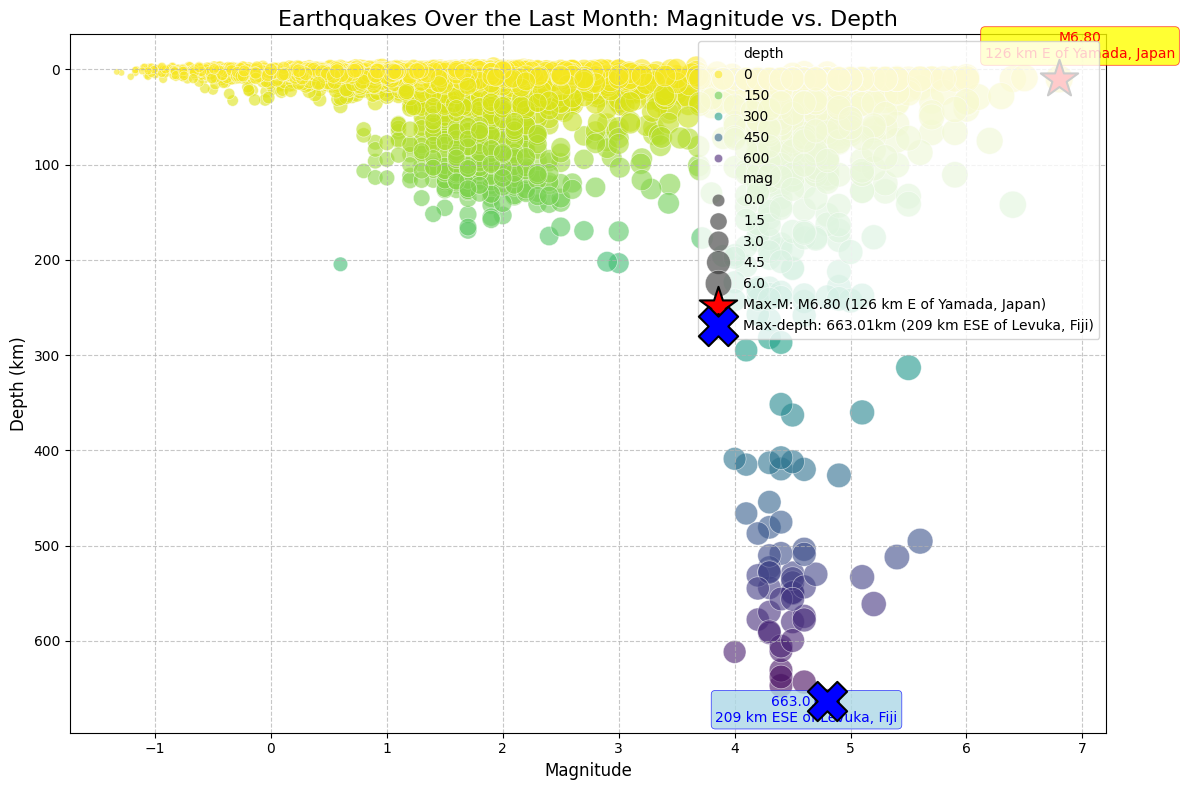

In [44]:
import matplotlib.pyplot as plt 
import seaborn as sns         
import warnings

import pandas as pd
import requests
from io import StringIO
import warnings
import numpy as np
from datetime import timezone
import matplotlib.pyplot as plt
import seaborn as sns

try:
    warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)
except AttributeError:
    try:
        warnings.simplefilter(action='ignore', category=pd.core.common.SettingWithCopyWarning)
    except:
        pass 

CSV_URL = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.csv"

try:
    response = requests.get(CSV_URL)
    response.raise_for_status() 

    df = pd.read_csv(StringIO(response.text))
    
except requests.exceptions.RequestException as e:
    print(f"データの取得中にエラーが発生しました: {e}")
    exit()

df.dropna(subset=['mag', 'depth'], inplace=True)


max_mag_quake_row = df.loc[df['mag'].idxmax()]
max_depth_quake_row = df.loc[df['depth'].idxmax()]

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='mag',
    y='depth',
    hue='depth', 
    palette='viridis_r', 
    size='mag', 
    sizes=(20, 400), 
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)

plt.scatter(
    max_mag_quake_row['mag'],
    max_mag_quake_row['depth'],
    color='red',
    s=800, 
    marker='*', 
    edgecolor='black',
    linewidth=1.5,
    zorder=5, 
    label=f"Max-M: M{max_mag_quake_row['mag']:.2f} ({max_mag_quake_row['place']})"
)
plt.annotate(
    f"M{max_mag_quake_row['mag']:.2f}\n{max_mag_quake_row['place']}",
    (max_mag_quake_row['mag'], max_mag_quake_row['depth']),
    textcoords="offset points",
    xytext=(15, 15),
    ha='center',
    fontsize=10,
    color='red',
    bbox=dict(boxstyle="round,pad=0.3", fc="yellow", ec="red", lw=0.5, alpha=0.8)
)

plt.scatter(
    max_depth_quake_row['mag'],
    max_depth_quake_row['depth'],
    color='blue',
    s=800, 
    marker='X', 
    edgecolor='black',
    linewidth=1.5,
    zorder=5,
    label=f"Max-depth: {max_depth_quake_row['depth']:.2f}km ({max_depth_quake_row['place']})"
)
plt.annotate(
    f"{max_depth_quake_row['depth']:.2f}km\n{max_depth_quake_row['place']}",
    (max_depth_quake_row['mag'], max_depth_quake_row['depth']),
    textcoords="offset points",
    xytext=(-15, -15),
    ha='center',
    fontsize=10,
    color='blue',
    bbox=dict(boxstyle="round,pad=0.3", fc="lightblue", ec="blue", lw=0.5, alpha=0.8)
)

plt.title('Earthquakes Over the Last Month: Magnitude vs. Depth', fontsize=16)
plt.xlabel('Magnitude', fontsize=12)
plt.ylabel('Depth (km)', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', fontsize=10) 
plt.tight_layout()
plt.show()

**チャレンジ6（上級）: 地震のグローバルマップ作成**

- foliumまたはmatplotlibなどのマッピングライブラリを使用して、すべての地震を地図上にプロットしてください。
- 以下の特徴を追加してください：
    - 地震の位置をポイントで表示。
    - マグニチュードに基づいてポイントを色分け（例：<4.0は緑、4.0–6.0は黄色、>6.0は赤）。
    - ポイントにマウスを重ねると、地震の位置、マグニチュード、日本日付、深さを表示するツールチップを追加。

# 課題提出

### Theme: Impact Visualization Challenge
USGSのライブ地震データを使って、**Impact** を感じる可視化や分析を作ってください。  
自分で考えて、探して、形にしてください。説明や手順はありません。

---

### How to Begin
1. **VS Code** を開く  
2. 自分の **GitHub「me」リポジトリ** の中に **新しいフォルダ** を作成 → 名前は **Week6**  
3. その中に **earthquake.ipynb** というファイルを作る  
4. **Markdown cell** を追加して、タイトルと自分の作品の説明を書く  
5. **Code cell** を追加し、ライブラリと **USGS データ** をインポートする（授業で使ったコードをコピー）  
6. さらに自分の **code cells** を追加して、可視化や分析を完成させる  

---

### 提出内容
- **Jupyter Notebook (.ipynb)**（code cells と markdown cells を含む）  
- **図または地図**（image または HTML）  
- **日本語サマリー（200〜400字）**：やったこと・わかったこと・感じたこと  

---

### 提出方法
成果物を **GitHub** にコミットし、`.ipynb` への **direct link** を **UNIPA** に提出。  
ファイルのアップロードは禁止。

---

### 評価
- **9–10：素晴らしい**  
- **7–8：ま〜ま〜**  
- **6：ギリOK**  
- **0：未提出**